# Mumbai AQI Dataset — 5-Year Expansion (v2)

In [1]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import numpy as np
from datetime import date

# Setup Open-Meteo client with cache and retry
cache_session  = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session  = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo      = openmeteo_requests.Client(session=retry_session)

# Mumbai coordinates
LATITUDE  = 19.0760
LONGITUDE = 72.8777

# 5-year window
START_DATE = '2020-01-01'
END_DATE   = '2024-12-31'

print(f'Fetching data: {START_DATE} → {END_DATE}')
print(f'Expected rows: ~{(date(2024,12,31) - date(2020,1,1)).days * 24:,} hourly records')

Fetching data: 2020-01-01 → 2024-12-31
Expected rows: ~43,824 hourly records


In [2]:
# ── Air Quality API ──────────────────────────────────────────────────────────
AQ_URL = 'https://air-quality-api.open-meteo.com/v1/air-quality'

aq_params = {
    'latitude':   LATITUDE,
    'longitude':  LONGITUDE,
    'hourly': [
        'pm10',
        'pm2_5',
        'carbon_monoxide',
        'nitrogen_dioxide',
        'sulphur_dioxide',
        'ozone',
        'ammonia',          # NEW: secondary PM2.5 precursor
        'us_aqi',
        'us_aqi_pm2_5',
        'us_aqi_pm10',
        'us_aqi_nitrogen_dioxide',
        'us_aqi_ozone',
        'dust',             # NEW: dust aerosol
    ],
    'start_date': START_DATE,
    'end_date':   END_DATE,
    'timezone':   'Asia/Kolkata',
}

aq_response = openmeteo.weather_api(AQ_URL, params=aq_params)[0]
aq_hourly   = aq_response.Hourly()

# Build DataFrame
aq_vars    = aq_params['hourly']
aq_data    = {
    'time': pd.date_range(
        start=pd.to_datetime(aq_hourly.Time(), unit='s', utc=True),
        end=pd.to_datetime(aq_hourly.TimeEnd(), unit='s', utc=True),
        freq=pd.Timedelta(seconds=aq_hourly.Interval()),
        inclusive='left'
    ).tz_convert('Asia/Kolkata'),
}
for i, var in enumerate(aq_vars):
    aq_data[var] = aq_hourly.Variables(i).ValuesAsNumpy()

df_aq = pd.DataFrame(aq_data)
print(f'Air quality data: {df_aq.shape[0]:,} rows × {df_aq.shape[1]} columns')
df_aq.head(3)

Air quality data: 43,848 rows × 14 columns


,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,ammonia,us_aqi,us_aqi_pm2_5,us_aqi_pm10,us_aqi_nitrogen_dioxide,us_aqi_ozone,dust
0,2020-01-01 00:00:00+05:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00+05:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 02:00:00+05:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── Weather API ───────────────────────────────────────────────────────────────
WX_URL = 'https://archive-api.open-meteo.com/v1/archive'

wx_params = {
    'latitude':   LATITUDE,
    'longitude':  LONGITUDE,
    'hourly': [
        'temperature_2m',
        'relative_humidity_2m',
        'dew_point_2m',              # NEW: aerosol hygroscopic growth
        'precipitation',
        'surface_pressure',
        'wind_speed_10m',
        'wind_direction_10m',
        'wind_gusts_10m',            # NEW: dispersion events
        'visibility',                # NEW: fog/haze proxy (metres)
        'uv_index',                  # NEW: photochemical O3 driver
        'boundary_layer_height',     # NEW: traps / disperses pollutants
        'cloud_cover',               # solar radiation proxy
        'et0_fao_evapotranspiration', # evaporation → humidity feedback
        'shortwave_radiation',        # photochemistry driver
    ],
    'start_date': START_DATE,
    'end_date':   END_DATE,
    'timezone':   'Asia/Kolkata',
}

wx_response = openmeteo.weather_api(WX_URL, params=wx_params)[0]
wx_hourly   = wx_response.Hourly()

wx_vars  = wx_params['hourly']
wx_data  = {
    'time': pd.date_range(
        start=pd.to_datetime(wx_hourly.Time(), unit='s', utc=True),
        end=pd.to_datetime(wx_hourly.TimeEnd(), unit='s', utc=True),
        freq=pd.Timedelta(seconds=wx_hourly.Interval()),
        inclusive='left'
    ).tz_convert('Asia/Kolkata'),
}
for i, var in enumerate(wx_vars):
    wx_data[var] = wx_hourly.Variables(i).ValuesAsNumpy()

df_wx = pd.DataFrame(wx_data)
print(f'Weather data: {df_wx.shape[0]:,} rows × {df_wx.shape[1]} columns')
df_wx.head(3)

Weather data: 43,848 rows × 15 columns


,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,wind_gusts_10m,visibility,uv_index,boundary_layer_height,cloud_cover,et0_fao_evapotranspiration,shortwave_radiation
0,2020-01-01 00:00:00+05:30,16.850000,86.314812,14.55,0.0,1012.584045,8.496305,36.384449,11.879999,NaN,NaN,150.0,0.0,0.000966,0.0
1,2020-01-01 01:00:00+05:30,16.299999,88.809906,14.45,0.0,1011.983154,8.891343,31.759439,12.240000,NaN,NaN,135.0,0.0,0.000000,0.0
2,2020-01-01 02:00:00+05:30,16.250000,88.233444,14.30,0.0,1011.283447,9.107359,18.435053,12.599999,NaN,NaN,125.0,0.0,0.000000,0.0


In [4]:
# ── Merge ─────────────────────────────────────────────────────────────────────
df = pd.merge(df_aq, df_wx, on='time', how='inner')
df = df.sort_values('time').reset_index(drop=True)
print(f'Merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Drop rows where target (us_aqi) is NaN
df = df.dropna(subset=['us_aqi'])
print(f'After dropping NaN targets: {df.shape[0]:,} rows')

Merged dataset: 43,848 rows × 28 columns
After dropping NaN targets: 21,115 rows


In [5]:
# ── Feature Engineering ───────────────────────────────────────────────────────

# 1. Temporal features
df['hour']         = df['time'].dt.hour
df['day_of_week']  = df['time'].dt.dayofweek        # 0=Mon
df['month']        = df['time'].dt.month
df['week_of_year'] = df['time'].dt.isocalendar().week.astype(int)
df['year']         = df['time'].dt.year
df['day_of_year']  = df['time'].dt.dayofyear
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)

# 2. Cyclical encodings — captures periodicity without discontinuity
df['hour_sin']   = np.sin(2 * np.pi * df['hour']  / 24)
df['hour_cos']   = np.cos(2 * np.pi * df['hour']  / 24)
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']    = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']    = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Temporal features added.')

Temporal features added.


In [6]:
# 3. Lag features — AQI autocorrelation
for lag in [1, 2, 3, 6, 12, 24, 48, 72]:
    df[f'aqi_lag_{lag}'] = df['us_aqi'].shift(lag)

# PM2.5 lags — dominant pollutant
for lag in [1, 3, 6, 24]:
    df[f'pm25_lag_{lag}'] = df['pm2_5'].shift(lag)

# Precipitation lag — washout / wet deposition takes time
for lag in [1, 3, 6, 12, 24]:
    df[f'precip_lag_{lag}'] = df['precipitation'].shift(lag)

# Wind speed lag
for lag in [1, 6]:
    df[f'wind_lag_{lag}'] = df['wind_speed_10m'].shift(lag)

print('Lag features added.')

Lag features added.


In [7]:
# 4. Rolling statistics
df['aqi_roll_mean_3']  = df['us_aqi'].rolling(3,  min_periods=1).mean()
df['aqi_roll_mean_6']  = df['us_aqi'].rolling(6,  min_periods=1).mean()
df['aqi_roll_mean_12'] = df['us_aqi'].rolling(12, min_periods=1).mean()
df['aqi_roll_mean_24'] = df['us_aqi'].rolling(24, min_periods=1).mean()
df['aqi_roll_mean_48'] = df['us_aqi'].rolling(48, min_periods=1).mean()
df['aqi_roll_std_24']  = df['us_aqi'].rolling(24, min_periods=1).std()
df['aqi_roll_max_24']  = df['us_aqi'].rolling(24, min_periods=1).max()
df['aqi_roll_min_24']  = df['us_aqi'].rolling(24, min_periods=1).min()

df['pm25_roll_mean_24'] = df['pm2_5'].rolling(24, min_periods=1).mean()
df['pm25_roll_max_24']  = df['pm2_5'].rolling(24, min_periods=1).max()

# Rolling precipitation — cumulative washout window
df['precip_sum_6h']  = df['precipitation'].rolling(6,  min_periods=1).sum()
df['precip_sum_24h'] = df['precipitation'].rolling(24, min_periods=1).sum()

print('Rolling statistics added.')

Rolling statistics added.


In [8]:
# 5. Mumbai Season flag
# Based on IMD climatology for Mumbai
def get_mumbai_season(month):
    if month in [6, 7, 8, 9]:       return 'monsoon'       # Jun–Sep: high rainfall, lower AQI
    elif month in [10, 11]:          return 'post_monsoon'  # Oct–Nov: transition, improving air
    elif month in [12, 1, 2]:        return 'winter'        # Dec–Feb: worst AQI (stagnant air)
    else:                            return 'summer'         # Mar–May: hot, dusty

df['season'] = df['month'].apply(get_mumbai_season)

# Dummy-encode seasons (drop='monsoon' as reference)
season_dummies = pd.get_dummies(df['season'], prefix='season', drop_first=False, dtype=int)
df = pd.concat([df, season_dummies], axis=1)
df.drop(columns=['season_monsoon'], errors='ignore', inplace=True)

print('Season features added.')

Season features added.


In [9]:
# 6. Festival / Pollution-event flags
# Mumbai-specific events linked to AQI spikes

# Known Diwali dates (approximate; fireworks → PM2.5 & PM10 spikes)
DIWALI_DATES = [
    '2020-11-14', '2021-11-04', '2022-10-24', '2023-11-12', '2024-11-01'
]
# Holi dates (bonfires → CO, BC spikes)
HOLI_DATES = [
    '2020-03-10', '2021-03-29', '2022-03-18', '2023-03-08', '2024-03-25'
]
# Ganesh Chaturthi immersion days (firecrackers + crowd vehicles)
GANESH_DATES = [
    '2020-09-01', '2021-09-19', '2022-09-09', '2023-09-28', '2024-09-17'
]

festival_dates = set(DIWALI_DATES + HOLI_DATES + GANESH_DATES)

# Mark the festival day AND +1 day after (pollution lingers)
festival_date_dt = set(pd.to_datetime(list(festival_dates)).date)
festival_plus1   = set([(d + pd.Timedelta('1D')).date() for d in pd.to_datetime(list(festival_dates))])
all_festival_days = festival_date_dt | festival_plus1

df['is_festival'] = df['time'].dt.date.isin(all_festival_days).astype(int)

print(f'Festival flag added. Festival + next-day hours: {df["is_festival"].sum():,}')

Festival flag added. Festival + next-day hours: 384


In [10]:
# 7. Interaction / derived features

# Ventilation index: higher = better pollutant dispersal
# (boundary layer height × wind speed)
if 'boundary_layer_height' in df.columns:
    df['ventilation_idx'] = df['boundary_layer_height'] * df['wind_speed_10m'] / 1000  # normalise

# Moisture × PM2.5 interaction — hygroscopic growth of particles in humid conditions
df['humidity_pm25'] = df['relative_humidity_2m'] * df['pm2_5'] / 100

# Temperature inversion proxy: low boundary layer + stable pressure = trapping
if 'boundary_layer_height' in df.columns:
    df['inversion_proxy'] = (df['boundary_layer_height'] < 500).astype(int)

# Wind direction categorised (N/NE/E/SE/S/SW/W/NW)
df['wind_dir_cat'] = pd.cut(
    df['wind_direction_10m'],
    bins=[0, 45, 90, 135, 180, 225, 270, 315, 360],
    labels=['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
    right=False,
).astype(str)

# Wind direction dummies (ocean SW winds off Arabian Sea = cleaner air in monsoon)
wind_dummies = pd.get_dummies(df['wind_dir_cat'], prefix='wdir', drop_first=True, dtype=int)
df = pd.concat([df, wind_dummies], axis=1)
df.drop(columns=['wind_dir_cat'], inplace=True)

print('Interaction and derived features added.')
print(f'Final dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

Interaction and derived features added.
Final dataset: 21,115 rows × 87 columns


In [11]:
# ── Quality Checks ────────────────────────────────────────────────────────────

print('=== Dataset Summary ===')
print(f'Date range : {df["time"].min()} → {df["time"].max()}')
print(f'Total rows : {len(df):,}')
print(f'Total cols : {df.shape[1]}')
print()

# Missing value report
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)
print(f'Columns with missing values ({len(missing_df)}):')
print(missing_df.head(20))

# Drop rows where >30% of key features are NaN (data quality threshold)
key_cols = ['us_aqi', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'temperature_2m',
            'relative_humidity_2m', 'wind_speed_10m']
before = len(df)
df = df.dropna(subset=key_cols)
print(f'\nDropped {before - len(df):,} rows with NaN in key columns. Remaining: {len(df):,}')

=== Dataset Summary ===
Date range : 2022-08-05 05:00:00+05:30 → 2024-12-31 23:00:00+05:30
Total rows : 21,115
Total cols : 87

Columns with missing values (26):
                       missing     pct
ammonia                  21115  100.00
visibility               21115  100.00
uv_index                 21115  100.00
boundary_layer_height     4368   20.69
ventilation_idx           4368   20.69
aqi_lag_72                  72    0.34
us_aqi_ozone                56    0.27
aqi_lag_48                  48    0.23
aqi_lag_24                  24    0.11
precip_lag_24               24    0.11
pm25_lag_24                 24    0.11
aqi_lag_12                  12    0.06
precip_lag_12               12    0.06
aqi_lag_6                    6    0.03
wind_lag_6                   6    0.03
precip_lag_6                 6    0.03
pm25_lag_6                   6    0.03
aqi_lag_3                    3    0.01
pm25_lag_3                   3    0.01
aqi_lag_2                    2    0.01

Dropped 0 rows wit

In [13]:
# ── Forward-fill minor gaps ────────────────────────────────────────────────────
non_target_cols = [c for c in df.columns if c not in ['us_aqi', 'time']]
df[non_target_cols] = df[non_target_cols].ffill(limit=3)

# Only numeric columns can have medians
numeric_cols = df[non_target_cols].select_dtypes(include='number').columns

medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)

print(f'Remaining NaNs after fill: {df.isnull().sum().sum()}')

Remaining NaNs after fill: 63345


In [14]:
# ── Save ──────────────────────────────────────────────────────────────────────
import os
os.makedirs('data', exist_ok=True)

out_path = 'data/mumbai_aqi_5yr_expanded.csv'
df.to_csv(out_path, index=False)
print(f'Saved to: {out_path}')
print(f'File size: {os.path.getsize(out_path) / 1e6:.1f} MB')
print()
print('=== Final shape ===')
print(f'Rows     : {len(df):,}')
print(f'Columns  : {df.shape[1]}')
print()
print('Key column groups:')
groups = {
    'Pollutants':       [c for c in df.columns if c in ['pm2_5','pm10','nitrogen_dioxide','ozone','sulphur_dioxide','carbon_monoxide','ammonia','dust']],
    'Weather':          [c for c in df.columns if c in ['temperature_2m','relative_humidity_2m','dew_point_2m','precipitation','surface_pressure','wind_speed_10m','wind_direction_10m','wind_gusts_10m','visibility','uv_index','boundary_layer_height','cloud_cover','shortwave_radiation']],
    'AQI lags':         [c for c in df.columns if 'aqi_lag' in c],
    'Rolling stats':    [c for c in df.columns if 'roll' in c],
    'Temporal':         [c for c in df.columns if c in ['hour','day_of_week','month','week_of_year','year','is_weekend','is_festival']],
    'Cyclical':         [c for c in df.columns if '_sin' in c or '_cos' in c],
    'Season dummies':   [c for c in df.columns if 'season_' in c],
    'Interactions':     [c for c in df.columns if c in ['ventilation_idx','humidity_pm25','inversion_proxy']],
}
for group, cols in groups.items():
    print(f'  {group:20s}: {len(cols):3d} → {cols}')

Saved to: data/mumbai_aqi_5yr_expanded.csv
File size: 15.1 MB

=== Final shape ===
Rows     : 21,115
Columns  : 87

Key column groups:
  Pollutants          :   8 → ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'ammonia', 'dust']
  Weather             :  13 → ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'visibility', 'uv_index', 'boundary_layer_height', 'cloud_cover', 'shortwave_radiation']
  AQI lags            :   8 → ['aqi_lag_1', 'aqi_lag_2', 'aqi_lag_3', 'aqi_lag_6', 'aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48', 'aqi_lag_72']
  Rolling stats       :  10 → ['aqi_roll_mean_3', 'aqi_roll_mean_6', 'aqi_roll_mean_12', 'aqi_roll_mean_24', 'aqi_roll_mean_48', 'aqi_roll_std_24', 'aqi_roll_max_24', 'aqi_roll_min_24', 'pm25_roll_mean_24', 'pm25_roll_max_24']
  Temporal            :   7 → ['hour', 'day_of_week', 'month', 'week_of_year', 'year', 'is_w

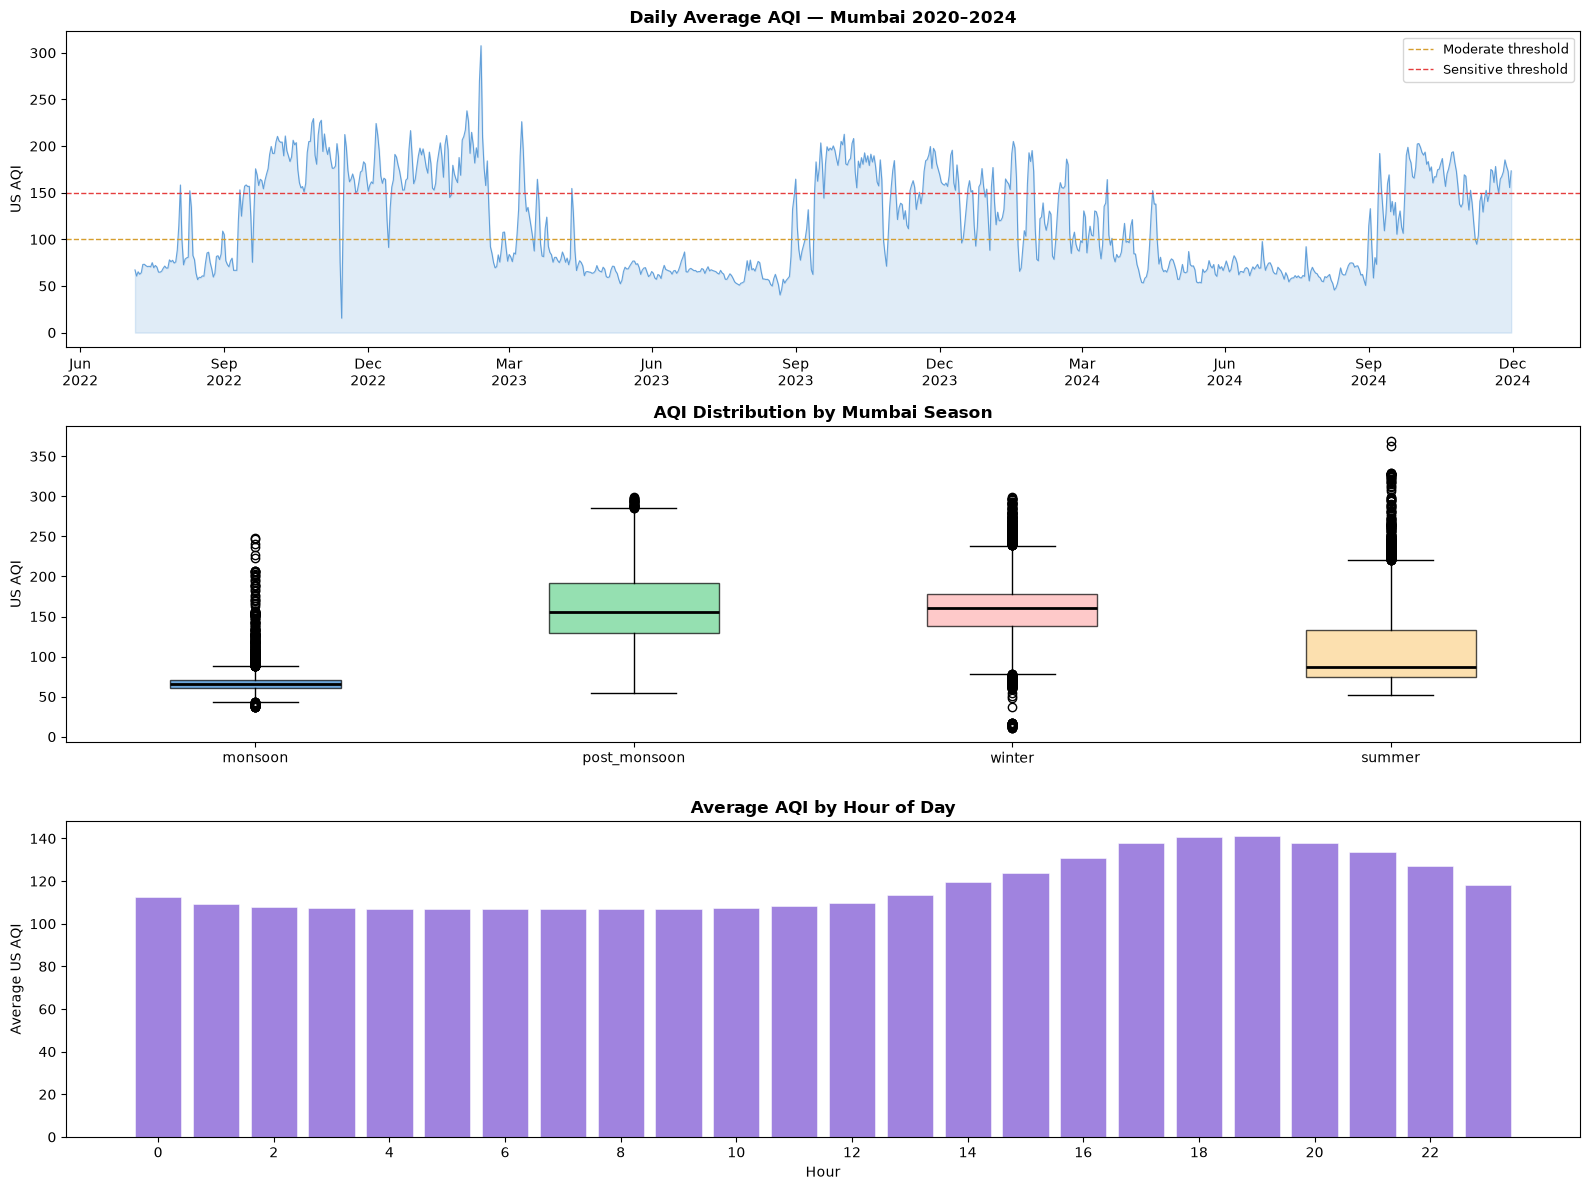

EDA plot saved to data/eda_overview.png


In [16]:
# ── Quick EDA plots ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# AQI over 5 years
daily = df.set_index('time')['us_aqi'].resample('D').mean()
axes[0].plot(daily.index, daily.values, lw=0.8, color='#3182ce', alpha=0.7)
axes[0].fill_between(daily.index, daily.values, alpha=0.15, color='#3182ce')
axes[0].axhline(100, ls='--', color='#d69e2e', lw=1, label='Moderate threshold')
axes[0].axhline(150, ls='--', color='#e53e3e', lw=1, label='Sensitive threshold')
axes[0].set_title('Daily Average AQI — Mumbai 2020–2024', fontweight='bold')
axes[0].set_ylabel('US AQI')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

# Seasonal box plot
from matplotlib.patches import Patch
season_order = ['monsoon', 'post_monsoon', 'winter', 'summer']
season_colors = {'monsoon': '#3182ce', 'post_monsoon': '#68d391', 'winter': '#feb2b2', 'summer': '#fbd38d'}
df_plot = df.copy()
df_plot['season_label'] = df_plot['month'].apply(get_mumbai_season)
grouped = [df_plot[df_plot['season_label'] == s]['us_aqi'].dropna() for s in season_order]
bp = axes[1].boxplot(grouped, tick_labels=season_order, patch_artist=True, medianprops=dict(color='black',lw=2))
for patch, s in zip(bp['boxes'], season_order):
    patch.set_facecolor(season_colors[s])
    patch.set_alpha(0.7)
axes[1].set_title('AQI Distribution by Mumbai Season', fontweight='bold')
axes[1].set_ylabel('US AQI')

# Hourly pattern
hourly_mean = df.groupby('hour')['us_aqi'].mean()
axes[2].bar(hourly_mean.index, hourly_mean.values, color='#805ad5', alpha=0.75, edgecolor='white', lw=0.5)
axes[2].set_title('Average AQI by Hour of Day', fontweight='bold')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Average US AQI')
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plot saved to data/eda_overview.png')